# Modelo de IA: Bayesian Knowledge Tracing (BKT)

**Projeto:** Fake News Fact Checker (jogo adaptativo de checagem de notícias)
**Residência em IA (ELD/UnB), Turma 1. Primeiro desafio, entrega do modelo**

Este notebook traz o modelo utilizado no projeto da equipe 2 e avalia o modelo de IA que foi um **Bayesian Knowledge Tracing** um modelo que estima, para cada jogador, a probabilidade de ele **dominar** cada uma das quatro habilidades de checagem:

| Código | Habilidade |
|---|---|
| `SOURCE` | analisar a origem/fonte da informação |
| `EVIDENCE` | avaliar as evidências que sustentam a alegação |
| `CONTEXT` | perceber contexto omitido, distorcido ou incompatível |
| `VISUAL` | verificar se uma imagem realmente sustenta a alegação |

A cada resposta do jogador, o BKT atualiza o domínio da habilidade correspondente. O seletor de perguntas usa esse valor para escolher a próxima rodada: prioriza a habilidade com **menor domínio** e a pergunta de dificuldade mais próxima desse domínio.

**Roteiro:**
1. Como o BKT funciona (teoria e exemplo numérico com o motor do projeto)
2. Dados: o que existe de real e a base simulada usada para calibrar e avaliar
3. Preparação dos dados e divisão treino/teste por jogador
4. Treinamento: estimação dos parâmetros por máxima verossimilhança
5. Avaliação: previsão da próxima resposta, estimativa de domínio, recuperação de parâmetros e estabilidade
6. Sensibilidade: o efeito do `p_guess` atual do backend
7. Execução nos dados reais disponíveis
8. Persistência do modelo (`.pkl`) e uso a partir do arquivo salvo

## 1. Como o BKT funciona

O BKT (Corbett & Anderson, 1995) modela o conhecimento de uma habilidade como um **estado oculto binário**: a pessoa **domina** ($L$) ou **ainda não domina** ($\neg L$). Esse estado não é observado diretamente. O que se observa é a resposta a cada pergunta: **correta** ou **incorreta**. É um Modelo Oculto de Markov (HMM) com dois estados e duas observações, definido por quatro parâmetros:

| Parâmetro | Significado | No jogo |
|---|---|---|
| $P(L_0)$ `p_init` | probabilidade de já dominar antes da 1ª pergunta | conhecimento prévio do jogador |
| $P(T)$ `p_transition` | probabilidade de passar de "não domina" para "domina" após uma oportunidade | aprendizado com o feedback/explicação da rodada |
| $P(G)$ `p_guess` | probabilidade de acertar **sem** dominar | "chute"; com 3 alternativas, o chute puro vale ≈ 1/3 |
| $P(S)$ `p_slip` | probabilidade de errar **mesmo** dominando | desatenção, erro de clique |

```
            P(T)                       acerta com prob. 1 − P(S)
  ┌──────────────────┐        domina ───────────────────────────►  resposta
  │                  ▼          ▲
não domina ───────► domina      │ (não há "esquecimento")
  │  1 − P(T)                   │
  └─► acerta com prob. P(G) ────┘
```

**Atualização após cada resposta** (implementada em `src/bkt_engine.py`, cópia fiel de `backend/app/bkt/engine.py`):

1. **Observação (regra de Bayes).** Corrige a crença de domínio $P(L_t)$ com a evidência:

$$P(L_t \mid \text{acerto}) = \frac{P(L_t)\,(1-P(S))}{P(L_t)\,(1-P(S)) + (1-P(L_t))\,P(G)}
\qquad
P(L_t \mid \text{erro}) = \frac{P(L_t)\,P(S)}{P(L_t)\,P(S) + (1-P(L_t))\,(1-P(G))}$$

2. **Transição (aprendizagem).** A pessoa pode aprender com a rodada (o jogo sempre mostra a explicação):

$$P(L_{t+1}) = P(L_t \mid \text{obs}) + \big(1 - P(L_t \mid \text{obs})\big)\,P(T)$$

**Previsão da próxima resposta.** Antes de ver a resposta, o modelo prevê
$$P(\text{acerto}_t) = P(L_t)\,(1-P(S)) + (1-P(L_t))\,P(G).$$
Essa previsão é o que se avalia: um bom BKT dá probabilidade alta de acerto a quem acerta e baixa a quem erra.

**Intuição dos parâmetros:**
- $P(G)$ alto faz um acerto valer pouco ("pode ter sido chute").
- $P(S)$ baixo faz um erro pesar muito ("quem domina quase nunca erra").
- $P(T)$ controla quanto o domínio sobe a cada rodada, mesmo com erro.

**No backend:** `AnswerService.process_answer` corrige a resposta, lê o `UserSkillState` (domínio atual, que começa em 0,30) e chama `BKTManager.update(skill, domínio, correta)`. O manager despacha para o tracker da habilidade (`SourceTracker`, `EvidenceTracker`, `ContextTracker`, `VisualTracker`), e o novo domínio é gravado na mesma transação da resposta. Hoje os quatro trackers usam os mesmos valores, definidos à mão: `p_init=0.30`, `p_guess=0.20`, `p_slip=0.05`, `p_transition=0.10`. Este notebook verifica se esses valores fazem sentido e mostra como calibrá-los a partir de dados.

In [1]:
from pathlib import Path
from datetime import datetime, timezone
import pickle
import platform
import sqlite3
import sys

import matplotlib
import matplotlib.ticker
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import sklearn
from scipy.optimize import minimize
from sklearn.calibration import calibration_curve
from sklearn.metrics import (accuracy_score, brier_score_loss, f1_score, log_loss,
                             precision_score, recall_score, roc_auc_score)
from sklearn.model_selection import GroupKFold, GroupShuffleSplit

# Pasta da entrega: funciona rodando de notebooks/ ou da raiz da entrega/repositório
ENTREGA = Path.cwd().resolve()
if ENTREGA.name == 'notebooks':
    ENTREGA = ENTREGA.parent
elif (ENTREGA / 'entrega_modelo_ia').is_dir():
    ENTREGA = ENTREGA / 'entrega_modelo_ia'
sys.path.insert(0, str(ENTREGA / 'src'))

from bkt_engine import BKTEngine  # mesmo código de backend/app/bkt/engine.py

FIGURAS = ENTREGA / 'figuras'
MODELOS = ENTREGA / 'modelos'
DADOS = ENTREGA / 'dados'
for pasta in (FIGURAS, MODELOS):
    pasta.mkdir(exist_ok=True)

SEED = 20261009
SKILLS = ['SOURCE', 'EVIDENCE', 'CONTEXT', 'VISUAL']   # mesma ordem do BKTManager
PARAMS = ['p_init', 'p_guess', 'p_slip', 'p_transition']

# Valores fixos usados hoje pelos quatro trackers do backend
PARAMS_BACKEND = {'p_init': 0.30, 'p_guess': 0.20, 'p_slip': 0.05, 'p_transition': 0.10}

# Cores fixas por habilidade (paleta categórica validada para daltonismo)
COR = {'SOURCE': '#2a78d6', 'EVIDENCE': '#eb6834', 'CONTEXT': '#1baf7a', 'VISUAL': '#eda100'}
CINZA = '#8a8984'
plt.rcParams.update({
    'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e4e3df', 'grid.linewidth': 0.8,
    'lines.linewidth': 2, 'axes.titleweight': 'bold', 'font.size': 10,
})

print('Python', platform.python_version(), '| numpy', np.__version__, '| pandas', pd.__version__,
      '| scipy', scipy.__version__, '| scikit-learn', sklearn.__version__, '| matplotlib', matplotlib.__version__)
print('Pasta da entrega:', ENTREGA.name, '| motor importado de src/bkt_engine.py')

Python 3.14.6 | numpy 2.5.3 | pandas 3.0.6 | scipy 1.18.1 | scikit-learn 1.9.1 | matplotlib 3.11.2
Pasta da entrega: entrega_modelo_ia | motor importado de src/bkt_engine.py


### 1.1 Exemplo numérico com o motor do projeto

Um jogador começa com domínio 0,30 em `SOURCE` e acerta a primeira pergunta. Fazendo a conta à mão com os parâmetros do backend:

- Observação: $\dfrac{0{,}30 \times 0{,}95}{0{,}30 \times 0{,}95 + 0{,}70 \times 0{,}20} = \dfrac{0{,}285}{0{,}425} = 0{,}6706$
- Transição: $0{,}6706 + (1 - 0{,}6706)\times 0{,}10 = 0{,}7035$

O teste unitário `backend/tests/bkt/test_engine.py` espera exatamente esse valor. A célula abaixo confere o motor e calcula também o caso de erro.

In [2]:
motor = BKTEngine(**PARAMS_BACKEND)

apos_acerto = motor.update(0.30, correct=True)
apos_erro = motor.update(0.30, correct=False)
assert np.isclose(apos_acerto, 0.7035294118, atol=1e-9)

print(f'Domínio 0,30 -> acerto -> {apos_acerto:.4f}')
print(f'Domínio 0,30 -> erro   -> {apos_erro:.4f}')
print('P(acerto) prevista com domínio 0,30:',
      round(0.30 * (1 - motor.p_slip) + 0.70 * motor.p_guess, 4))

Domínio 0,30 -> acerto -> 0.7035
Domínio 0,30 -> erro   -> 0.1235
P(acerto) prevista com domínio 0,30: 0.425


Com esses parâmetros, **um único acerto** leva o domínio de 0,30 para 0,70, e **um único erro** o derruba para perto de 0,12. Isso acontece porque `p_slip=0,05` diz que quem domina quase nunca erra, e `p_guess=0,20` diz que quem não domina raramente acerta. Na seção 6 mostramos que essa segunda hipótese não vale para perguntas de 3 alternativas.

### 1.2 Trajetória de um jogador e efeito de cada parâmetro

À esquerda, a evolução do domínio numa sequência de respostas. À direita, a mesma sequência variando um parâmetro por vez.

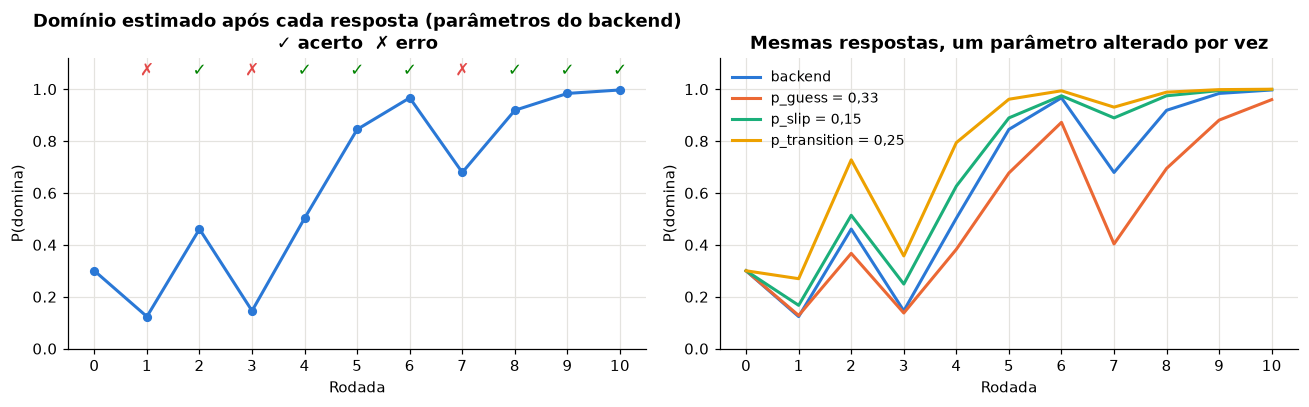

In [3]:
def trajetoria(respostas, p_init, p_guess, p_slip, p_transition):
    m = BKTEngine(p_guess=p_guess, p_slip=p_slip, p_transition=p_transition, p_init=p_init)
    dominio = [p_init]
    for r in respostas:
        dominio.append(m.update(dominio[-1], bool(r)))
    return np.array(dominio)

respostas_exemplo = [0, 1, 0, 1, 1, 1, 0, 1, 1, 1]
x = np.arange(len(respostas_exemplo) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
ax = axes[0]
ax.plot(x, trajetoria(respostas_exemplo, **PARAMS_BACKEND), color=COR['SOURCE'], marker='o', markersize=5)
for i, r in enumerate(respostas_exemplo, start=1):
    ax.annotate('✓' if r else '✗', (i, 1.07), ha='center', va='center', fontsize=11,
                color='#008300' if r else '#e34948')
ax.set(title='Domínio estimado após cada resposta (parâmetros do backend)\n✓ acerto  ✗ erro',
       xlabel='Rodada', ylabel='P(domina)', ylim=(0, 1.12), xticks=x)

ax = axes[1]
variacoes = [
    ('backend', PARAMS_BACKEND, COR['SOURCE'], '-'),
    ('p_guess = 0,33', {**PARAMS_BACKEND, 'p_guess': 0.33}, COR['EVIDENCE'], '-'),
    ('p_slip = 0,15', {**PARAMS_BACKEND, 'p_slip': 0.15}, COR['CONTEXT'], '-'),
    ('p_transition = 0,25', {**PARAMS_BACKEND, 'p_transition': 0.25}, COR['VISUAL'], '-'),
]
for nome, p, cor, estilo in variacoes:
    ax.plot(x, trajetoria(respostas_exemplo, **p), color=cor, linestyle=estilo, label=nome)
ax.set(title='Mesmas respostas, um parâmetro alterado por vez', xlabel='Rodada', ylabel='P(domina)', ylim=(0, 1.12), xticks=x)
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.savefig(FIGURAS / '01_trajetoria_e_sensibilidade.png', bbox_inches='tight')
plt.show()

O gráfico mostra o comportamento do modelo:
- Com `p_guess` maior (laranja), acertos convencem menos e a curva sobe mais devagar.
- Com `p_slip` maior (verde), erros derrubam menos, e o modelo tolera deslizes de quem já domina.
- Com `p_transition` maior (amarelo), o domínio cresce mais a cada rodada, independentemente do resultado.

Calibrar o BKT é escolher esses quatro números de forma que as previsões batam com o comportamento real dos jogadores.

## 2. Dados

### 2.1 O que existe de dado real

O BKT aprende com **sequências de respostas por jogador e habilidade** (`jogador, habilidade, correta, data`). Os CSVs de notícias em `EDA/datasets/` (usados na análise exploratória) são notícias rotuladas como falsas/verdadeiras, **não** respostas de jogadores. Por isso não servem para treinar o BKT.

O banco local do backend (`backend/fact_check.db`) tem 12 perguntas (3 por habilidade, todas com 3 alternativas) e apenas **10 respostas**, de um usuário de teste da equipe. Exportamos essas respostas, sem identificador de usuário, para `dados/respostas_teste_local.csv`. Elas são usadas na seção 7 para executar o modelo, mas são poucas demais para estimar parâmetros.

In [4]:
CSV_REAL = DADOS / 'respostas_teste_local.csv'
respostas_reais = pd.read_csv(CSV_REAL, parse_dates=['created_at'])
print(f'{len(respostas_reais)} respostas reais | taxa de acerto {respostas_reais.correct.mean():.0%}')
respostas_reais.groupby('skill_code')['correct'].agg(respostas='size', acertos='sum').reindex(SKILLS)

10 respostas reais | taxa de acerto 40%


,respostas,acertos
skill_code,,
SOURCE,3,1
EVIDENCE,3,1
CONTEXT,1,1
VISUAL,3,1


### 2.2 Base simulada (decisão de projeto)

Sem histórico real suficiente, geramos uma base **sintética** a partir do próprio processo gerador do BKT, com parâmetros "verdadeiros" conhecidos, mas posteriormente corrigiremos para dados reais. Isso permite:
1. **validar o pipeline de treino** (o otimizador recupera os parâmetros que geraram os dados?);
2. medir o que **só é mensurável em simulação**: o acerto da estimativa de domínio contra o estado latente verdadeiro;
3. deixar o código pronto: ao substituir a base simulada por respostas reais no mesmo formato, o resto do notebook roda sem mudanças.

**Hipóteses da simulação (o que se quer validar com dados reais):**
- `p_guess` ≈ 1/3, porque todas as perguntas têm 3 alternativas;
- as habilidades têm dificuldades diferentes. `SOURCE` (fonte) é a mais intuitiva; `VISUAL` (imagem fora de contexto) é a menos intuitiva, com menor domínio inicial e aprendizado mais lento;
- `p_slip` entre 0,08 e 0,12, porque mesmo quem domina erra por pressa ou desatenção.

**Como o jogo é simulado (fiel ao backend):** cada jogador joga de 1 a 4 partidas de 10 rodadas. Em cada rodada, o seletor escolhe a habilidade de **menor domínio estimado** pelo BKT do backend, com empate resolvido pela ordem `SOURCE, EVIDENCE, CONTEXT, VISUAL`, como em `QuestionSelector`. A resposta é sorteada a partir do estado **latente verdadeiro** do jogador. Depois da resposta, ele pode aprender com probabilidade `p_transition`. Assumimos que o banco de perguntas não se esgota (hoje há só 12 perguntas; ver relatório). A dificuldade individual das perguntas não é modelada, porque o BKT clássico também não a considera.

In [5]:
PARAMS_VERDADEIROS = {
    'SOURCE':   {'p_init': 0.35, 'p_guess': 0.33, 'p_slip': 0.08, 'p_transition': 0.15},
    'EVIDENCE': {'p_init': 0.25, 'p_guess': 0.30, 'p_slip': 0.10, 'p_transition': 0.12},
    'CONTEXT':  {'p_init': 0.20, 'p_guess': 0.33, 'p_slip': 0.10, 'p_transition': 0.10},
    'VISUAL':   {'p_init': 0.15, 'p_guess': 0.30, 'p_slip': 0.12, 'p_transition': 0.08},
}
N_JOGADORES = 800
RODADAS_POR_PARTIDA = 10


def simular_jogadores(n_jogadores, params_verdadeiros, seed):
    rng = np.random.default_rng(seed)
    motor_backend = BKTEngine(**PARAMS_BACKEND)
    linhas = []
    inicio = pd.Timestamp('2026-09-01', tz='UTC')
    for j in range(n_jogadores):
        jogador = f'sim-{j:04d}'
        domina = {s: rng.random() < params_verdadeiros[s]['p_init'] for s in SKILLS}
        estimado = {s: PARAMS_BACKEND['p_init'] for s in SKILLS}   # UserSkillState inicial
        n_partidas = rng.integers(1, 5)
        t = 0
        for partida in range(n_partidas):
            for rodada in range(1, RODADAS_POR_PARTIDA + 1):
                # QuestionSelector: menor domínio estimado; empate pela ordem do BKTManager
                skill = min(SKILLS, key=lambda s: (estimado[s], SKILLS.index(s)))
                p = params_verdadeiros[skill]
                estado_antes = domina[skill]
                correta = rng.random() < ((1 - p['p_slip']) if estado_antes else p['p_guess'])
                if not domina[skill] and rng.random() < p['p_transition']:
                    domina[skill] = True
                estimado[skill] = motor_backend.update(estimado[skill], bool(correta))
                linhas.append({
                    'user_id': jogador, 'skill_code': skill, 'correct': int(correta),
                    'created_at': inicio + pd.Timedelta(minutes=t), 'game': partida + 1, 'round': rodada,
                    'domina_antes': int(estado_antes), 'domina_depois': int(domina[skill]),
                })
                t += 1
    return pd.DataFrame(linhas)


respostas = simular_jogadores(N_JOGADORES, PARAMS_VERDADEIROS, SEED)
print(f'{len(respostas):,} respostas | {respostas.user_id.nunique()} jogadores | '
      f'taxa de acerto geral {respostas.correct.mean():.1%}')
respostas.head()

20,150 respostas | 800 jogadores | taxa de acerto geral 51.3%


,user_id,skill_code,correct,created_at,game,round,domina_antes,domina_depois
0,sim-0000,SOURCE,0,2026-09-01 00:00:00+00:00,1,1,0,0
1,sim-0000,SOURCE,0,2026-09-01 00:01:00+00:00,1,2,0,0
2,sim-0000,SOURCE,0,2026-09-01 00:02:00+00:00,1,3,0,0
3,sim-0000,SOURCE,0,2026-09-01 00:03:00+00:00,1,4,0,0
4,sim-0000,SOURCE,0,2026-09-01 00:04:00+00:00,1,5,0,0


### 2.3 Análise exploratória da base simulada

,respostas,taxa_acerto,jogadores,respostas_por_jogador (mediana)
skill_code,,,,
SOURCE,4245,0.582,800,4.0
EVIDENCE,4868,0.519,799,5.0
CONTEXT,5086,0.519,790,5.0
VISUAL,5951,0.453,758,6.0


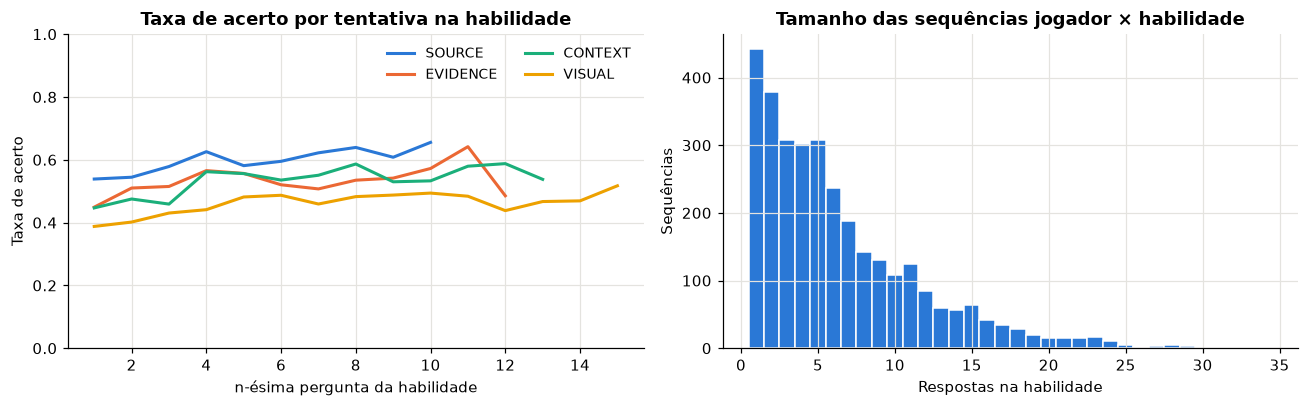

In [6]:
seq = respostas.groupby(['user_id', 'skill_code']).size().rename('respostas').reset_index()
resumo = respostas.groupby('skill_code').agg(
    respostas=('correct', 'size'), taxa_acerto=('correct', 'mean'),
    jogadores=('user_id', 'nunique')).reindex(SKILLS)
resumo['respostas_por_jogador (mediana)'] = seq.groupby('skill_code')['respostas'].median().reindex(SKILLS)
display(resumo.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
ax = axes[0]
for s in SKILLS:
    taxa = (respostas[respostas.skill_code == s]
            .assign(tentativa=lambda d: d.groupby('user_id').cumcount() + 1)
            .groupby('tentativa')['correct'].agg(['mean', 'size']))
    taxa = taxa[taxa['size'] >= 100]
    ax.plot(taxa.index, taxa['mean'], color=COR[s], label=s)
ax.set(title='Taxa de acerto por tentativa na habilidade', xlabel='n-ésima pergunta da habilidade',
       ylabel='Taxa de acerto', ylim=(0, 1))
ax.xaxis.set_major_locator(matplotlib.ticker.MaxNLocator(integer=True))
ax.legend(frameon=False, ncols=2, fontsize=9)

ax = axes[1]
bins = np.arange(0.5, seq['respostas'].max() + 1.5)
ax.hist(seq['respostas'], bins=bins, color=COR['SOURCE'], edgecolor='white', linewidth=1)
ax.set(title='Tamanho das sequências jogador × habilidade', xlabel='Respostas na habilidade',
       ylabel='Sequências')
plt.tight_layout()
plt.savefig(FIGURAS / '02_eda_base_simulada.png', bbox_inches='tight')
plt.show()

A taxa de acerto **sobe com a prática** em todas as habilidades. É exatamente o padrão que o BKT tenta explicar: quem ainda não domina vai aprendendo. As sequências são curtas (mediana de poucas respostas por habilidade) e de tamanho variável, porque o seletor adaptativo manda mais perguntas para a habilidade mais fraca. Esse é o cenário realista do jogo e o mais difícil para o modelo.

## 3. Preparação dos dados

- **Ordenação:** respostas ordenadas por `created_at` dentro de cada par jogador × habilidade. O BKT depende da ordem.
- **Formato:** cada par vira uma sequência de 0/1. Para treinar rápido, as sequências são empilhadas numa matriz com máscara (padding), e o filtro do BKT roda vetorizado sobre todas ao mesmo tempo.
- **Divisão treino/teste por jogador (70/30):** todas as respostas de um jogador ficam do mesmo lado. Assim o teste mede a generalização para **jogadores novos**, que é o uso real, e evita vazamento de informação de um mesmo jogador entre treino e teste.

In [7]:
def montar_sequencias(df, skill, extras=()):
    # Matriz (n_sequencias x tamanho_max) de respostas + máscara de posições válidas
    grupos = [g for _, g in df[df.skill_code == skill]
              .sort_values(['user_id', 'created_at'], kind='stable').groupby('user_id', sort=True)]
    n, T = len(grupos), max((len(g) for g in grupos), default=0)
    Y = np.zeros((n, T), dtype=int)
    M = np.zeros((n, T), dtype=bool)
    E = {c: np.zeros((n, T), dtype=int) for c in extras}
    for i, g in enumerate(grupos):
        k = len(g)
        Y[i, :k] = g['correct'].to_numpy()
        M[i, :k] = True
        for c in extras:
            E[c][i, :k] = g[c].to_numpy()
    return Y, M, E


divisor = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)
idx_treino, idx_teste = next(divisor.split(respostas, groups=respostas['user_id']))
treino, teste = respostas.iloc[idx_treino], respostas.iloc[idx_teste]
assert set(treino.user_id).isdisjoint(teste.user_id)

print(f'Treino: {treino.user_id.nunique()} jogadores, {len(treino):,} respostas')
print(f'Teste:  {teste.user_id.nunique()} jogadores, {len(teste):,} respostas')

Treino: 560 jogadores, 13,880 respostas
Teste:  240 jogadores, 6,270 respostas


## 4. Treinamento: estimação dos parâmetros por máxima verossimilhança

"Treinar" o BKT é encontrar, **para cada habilidade**, os quatro parâmetros que maximizam a probabilidade das sequências observadas. A verossimilhança é calculada pelo **algoritmo forward** do HMM, que é a mesma conta que o motor faz em produção: para cada resposta, prevê-se $P(\text{acerto}_t)$ com o domínio atual e depois atualiza-se o domínio com a resposta observada.

$$\text{NLL}(\theta) = -\sum_{\text{sequências}}\sum_t \Big[y_t \log P(\text{acerto}_t) + (1-y_t)\log\big(1-P(\text{acerto}_t)\big)\Big]$$

**Critérios da otimização:**
- **L-BFGS-B com limites.** `p_guess` e `p_slip` ficam abaixo de 0,5. Sem isso o BKT sofre de *degeneração* (Baker et al., 2008): o otimizador pode achar soluções em que "errar indica domínio".
- **Múltiplos pontos de partida (10).** A verossimilhança do BKT não é convexa e tem mínimos locais, então fica a melhor solução encontrada.
- **Um conjunto de parâmetros por habilidade**, como prevê a arquitetura (um tracker por skill). Para comparação, também ajustamos um conjunto **global** único.

In [8]:
LIMITES = {'p_init': (0.01, 0.99), 'p_guess': (0.01, 0.49), 'p_slip': (0.01, 0.49), 'p_transition': (0.001, 0.60)}


def filtro_bkt(params, Y, M):
    # Algoritmo forward do BKT, vetorizado sobre as sequências.
    # Retorna P(acerto) prevista ANTES de cada resposta e o domínio DEPOIS dela.
    L0, G, S, T = (params[k] for k in PARAMS)
    n, tam = Y.shape
    dominio = np.full(n, L0, dtype=float)
    p_acerto = np.zeros((n, tam))
    dominio_depois = np.zeros((n, tam))
    for t in range(tam):
        p = dominio * (1 - S) + (1 - dominio) * G
        p_acerto[:, t] = p
        y = Y[:, t] == 1
        posterior = np.where(y, dominio * (1 - S) / p, dominio * S / (1 - p))
        novo = posterior + (1 - posterior) * T
        dominio = np.where(M[:, t], novo, dominio)
        dominio_depois[:, t] = dominio
    return p_acerto, dominio_depois


def nll(vetor, Y, M):
    p, _ = filtro_bkt(dict(zip(PARAMS, vetor)), Y, M)
    p = np.clip(p[M], 1e-9, 1 - 1e-9)
    y = Y[M]
    return -np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))


def ajustar_bkt(Y, M, n_inicios=10, seed=SEED):
    rng = np.random.default_rng(seed)
    limites = [LIMITES[k] for k in PARAMS]
    inicios = [[PARAMS_BACKEND[k] for k in PARAMS]]
    inicios += [[rng.uniform(lo, hi) for lo, hi in limites] for _ in range(n_inicios - 1)]
    melhor = None
    for x0 in inicios:
        r = minimize(nll, x0, args=(Y, M), method='L-BFGS-B', bounds=limites)
        if melhor is None or r.fun < melhor.fun:
            melhor = r
    return {k: float(v) for k, v in zip(PARAMS, melhor.x)}, float(melhor.fun)


# Paridade: o filtro vetorizado reproduz exatamente o BKTEngine do backend
Y_chk, M_chk, _ = montar_sequencias(treino, 'SOURCE')
_, dom_vet = filtro_bkt(PARAMS_BACKEND, Y_chk, M_chk)
for i in range(50):
    d = PARAMS_BACKEND['p_init']
    for t in np.flatnonzero(M_chk[i]):
        d = motor.update(d, bool(Y_chk[i, t]))
        assert np.isclose(d, dom_vet[i, t], atol=1e-12)
print('Paridade com BKTEngine confirmada (filtro vetorizado == motor do backend).')

Paridade com BKTEngine confirmada (filtro vetorizado == motor do backend).


In [9]:
%%time
params_ajustados, nll_treino = {}, {}
for s in SKILLS:
    Y, M, _ = montar_sequencias(treino, s)
    params_ajustados[s], nll_treino[s] = ajustar_bkt(Y, M)

# Modelo global: um único conjunto para as 4 habilidades (sequências empilhadas)
blocos = [montar_sequencias(treino, s)[:2] for s in SKILLS]
T_max = max(Y.shape[1] for Y, _ in blocos)
Y_g = np.vstack([np.pad(Y, ((0, 0), (0, T_max - Y.shape[1]))) for Y, _ in blocos])
M_g = np.vstack([np.pad(M, ((0, 0), (0, T_max - M.shape[1]))) for _, M in blocos])
params_global, _ = ajustar_bkt(Y_g, M_g)

tabela_params = pd.concat({
    'ajustado': pd.DataFrame(params_ajustados).T,
    'verdadeiro (simulação)': pd.DataFrame(PARAMS_VERDADEIROS).T,
}, axis=1).swaplevel(axis=1)[[(p, c) for p in PARAMS for c in ('ajustado', 'verdadeiro (simulação)')]]
display(tabela_params.round(3))
print('Global (uma única configuração):', {k: round(v, 3) for k, v in params_global.items()})
print('Backend atual:                  ', PARAMS_BACKEND)

p_init                         p_guess                         \
         ajustado verdadeiro (simulação) ajustado verdadeiro (simulação)   
SOURCE      0.366                   0.35    0.315                   0.33   
EVIDENCE    0.256                   0.25    0.292                   0.30   
CONTEXT     0.226                   0.20    0.341                   0.33   
VISUAL      0.156                   0.15    0.280                   0.30   

           p_slip                        p_transition                         
         ajustado verdadeiro (simulação)     ajustado verdadeiro (simulação)  
SOURCE      0.095                   0.08        0.155                   0.15  
EVIDENCE    0.087                   0.10        0.119                   0.12  
CONTEXT     0.128                   0.10        0.105                   0.10  
VISUAL      0.129                   0.12        0.076                   0.08

Global (uma única configuração): {'p_init': 0.264, 'p_guess': 0.303, 'p_slip': 0.112, 'p_transition': 0.104}
Backend atual:                   {'p_init': 0.3, 'p_guess': 0.2, 'p_slip': 0.05, 'p_transition': 0.1}
CPU times: user 1.59 s, sys: 14.1 ms, total: 1.6 s
Wall time: 1.61 s


## 5. Avaliação

O BKT tem duas saídas, e cada uma é avaliada de um jeito:

| Saída | Pergunta | Como medimos |
|---|---|---|
| $P(\text{acerto}_t)$ | o modelo antecipa a próxima resposta? | **AUC-ROC**, **log-loss**, **Brier**, acurácia @0,5 e curva de calibração, no **teste** (jogadores nunca vistos) |
| $P(L_t)$ (o domínio exibido no perfil) | o domínio estimado reflete o estado real? | AUC e precisão/revocação da decisão "domina" (limiar 0,95, o usual em BKT) contra o estado latente **verdadeiro**, só mensurável na simulação |

**Modelos comparados:**
1. **Taxa global:** prevê sempre a taxa média de acerto do treino (referência mínima).
2. **Taxa por habilidade:** prevê a taxa média de acerto da habilidade.
3. **BKT backend:** parâmetros fixos atuais (0,30 / 0,20 / 0,05 / 0,10).
4. **BKT global ajustado:** um conjunto de parâmetros calibrado para todas as habilidades.
5. **BKT por habilidade ajustado:** o modelo proposto.
6. **Oráculo (teto teórico):** conhece o estado latente verdadeiro e os parâmetros verdadeiros. Não é um modelo utilizável; serve para mostrar o **máximo atingível**, já que até quem sabe tudo erra a previsão quando o jogador chuta certo ou se distrai.

Cada previsão é feita **antes** de ver a resposta, que depois atualiza o estado, como no uso online do jogo.

**Por que essas métricas:** AUC mede se o modelo *ordena* bem (acertos recebem probabilidade maior que erros) e não depende de limiar. Log-loss e Brier medem se as probabilidades estão *calibradas*, o que importa porque o domínio é mostrado ao jogador e guia o seletor de perguntas. A acurácia @0,5 entra só como referência intuitiva: com mais acertos que erros, ela fica inflada por qualquer modelo que preveja "acerta".

In [10]:
def prever(df, params_por_skill):
    # Concatena, para todas as habilidades, rótulo, P(acerto) prevista, domínio após a resposta e estado verdadeiro
    saida = []
    for s in SKILLS:
        Y, M, E = montar_sequencias(df, s, extras=('domina_antes', 'domina_depois'))
        p, dom = filtro_bkt(params_por_skill[s], Y, M)
        saida.append(pd.DataFrame({'skill_code': s, 'y': Y[M], 'p': p[M], 'dominio': dom[M],
                                   'domina_antes': E['domina_antes'][M],
                                   'domina_depois': E['domina_depois'][M],
                                   'tentativa': np.tile(np.arange(Y.shape[1]), (len(Y), 1))[M] + 1}))
    return pd.concat(saida, ignore_index=True)


def metricas(y, p):
    p = np.clip(p, 1e-9, 1 - 1e-9)
    return {'AUC': roc_auc_score(y, p), 'log-loss': log_loss(y, p, labels=[0, 1]),
            'Brier': brier_score_loss(y, p), 'acurácia@0,5': accuracy_score(y, p >= 0.5)}


modelos = {
    'BKT backend (fixo)': {s: PARAMS_BACKEND for s in SKILLS},
    'BKT global ajustado': {s: params_global for s in SKILLS},
    'BKT por habilidade ajustado': params_ajustados,
}
previsoes = {nome: prever(teste, p) for nome, p in modelos.items()}
base = previsoes['BKT por habilidade ajustado']

taxa_global = treino['correct'].mean()
taxa_skill = treino.groupby('skill_code')['correct'].mean()
linhas = {
    'Taxa global (baseline)': metricas(base.y, np.full(len(base), taxa_global)),
    'Taxa por habilidade (baseline)': metricas(base.y, base.skill_code.map(taxa_skill).to_numpy()),
}
linhas |= {nome: metricas(d.y, d.p) for nome, d in previsoes.items()}

# Teto teórico: um "oráculo" que conhece o estado latente verdadeiro e os parâmetros verdadeiros.
# Mesmo ele erra, porque quem não domina acerta por chute e quem domina às vezes erra.
g_v = base.skill_code.map({s: PARAMS_VERDADEIROS[s]['p_guess'] for s in SKILLS})
s_v = base.skill_code.map({s: PARAMS_VERDADEIROS[s]['p_slip'] for s in SKILLS})
linhas['Oráculo (teto teórico)'] = metricas(base.y, np.where(base.domina_antes == 1, 1 - s_v, g_v))
resultados = pd.DataFrame(linhas).T
print(f'Teste: {len(base):,} respostas de {teste.user_id.nunique()} jogadores | taxa de acerto {base.y.mean():.1%}')
resultados.round(4)

Teste: 6,270 respostas de 240 jogadores | taxa de acerto 51.5%


,AUC,log-loss,Brier,"acurácia@0,5"
Taxa global (baseline),0.5000,0.6927,0.2498,0.5145
Taxa por habilidade (baseline),0.5305,0.6918,0.2493,0.5273
BKT backend (fixo),0.6538,0.6683,0.2360,0.6161
BKT global ajustado,0.6547,0.6474,0.2284,0.6171
BKT por habilidade ajustado,0.6589,0.6462,0.2279,0.6171
Oráculo (teto teórico),0.7624,0.5211,0.1731,0.7571


In [11]:
por_skill = pd.DataFrame({
    s: {**{f'AUC {n.split(" (")[0].replace("BKT ", "")}': roc_auc_score(d[d.skill_code == s].y, d[d.skill_code == s].p)
           for n, d in previsoes.items()},
        'log-loss ajustado': log_loss(base[base.skill_code == s].y, base[base.skill_code == s].p),
        'log-loss backend': log_loss(previsoes['BKT backend (fixo)'].query('skill_code == @s').y,
                                     previsoes['BKT backend (fixo)'].query('skill_code == @s').p),
        'respostas': int((base.skill_code == s).sum())}
    for s in SKILLS}).T
por_skill.round(4)

,AUC backend,AUC global ajustado,AUC por habilidade ajustado,log-loss ajustado,log-loss backend,respostas
SOURCE,0.6616,0.6613,0.6613,0.6382,0.6630,1384.0
EVIDENCE,0.6670,0.6688,0.6686,0.6386,0.6544,1467.0
CONTEXT,0.6348,0.6373,0.6395,0.6532,0.6780,1691.0
VISUAL,0.6504,0.6507,0.6502,0.6523,0.6749,1728.0


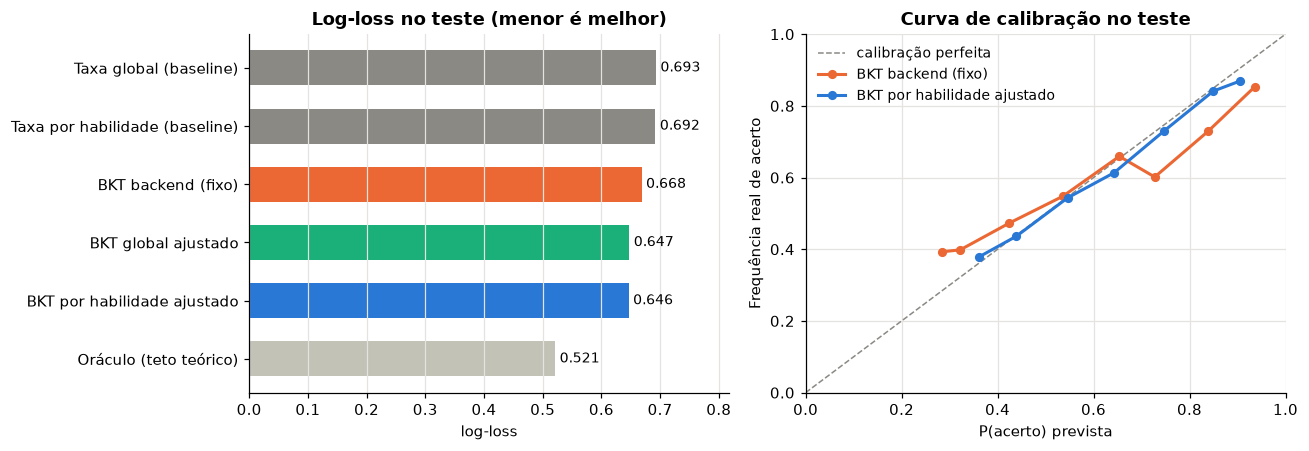

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

ax = axes[0]
ordem = resultados.index.tolist()
cores = [CINZA, CINZA, COR['EVIDENCE'], COR['CONTEXT'], COR['SOURCE'], '#c3c2b7']
barras = ax.barh(ordem[::-1], resultados['log-loss'][::-1], color=cores[::-1], height=0.6)
ax.bar_label(barras, fmt='%.3f', padding=3, fontsize=9)
ax.set(title='Log-loss no teste (menor é melhor)', xlabel='log-loss', xlim=(0, resultados['log-loss'].max() * 1.18))
ax.grid(axis='y', visible=False)

ax = axes[1]
ax.plot([0, 1], [0, 1], linestyle='--', color=CINZA, linewidth=1, label='calibração perfeita')
for nome, cor in [('BKT backend (fixo)', COR['EVIDENCE']), ('BKT por habilidade ajustado', COR['SOURCE'])]:
    d = previsoes[nome]
    frac, media = calibration_curve(d.y, d.p, n_bins=10, strategy='uniform')
    ax.plot(media, frac, marker='o', markersize=5, color=cor, label=nome)
ax.set(title='Curva de calibração no teste', xlabel='P(acerto) prevista', ylabel='Frequência real de acerto',
       xlim=(0, 1), ylim=(0, 1))
ax.legend(frameon=False, fontsize=9, loc='upper left')
plt.tight_layout()
plt.savefig(FIGURAS / '03_metricas_e_calibracao.png', bbox_inches='tight')
plt.show()

**Leitura:**
- **Baselines × BKT.** Os baselines não usam o histórico do jogador, então a AUC deles fica perto de 0,5. Os BKTs sobem para ≈ 0,65–0,66 porque usam o histórico de cada um.
- **Por que a AUC é moderada.** Mesmo o oráculo, que conhece o estado verdadeiro, chega a apenas ≈ 0,76. Com 3 alternativas, um terço dos jogadores que não dominam acerta por chute, e quem domina erra cerca de 10% das vezes: a resposta individual é ruidosa por natureza. O BKT calibrado cobre ≈ 60% da distância entre o acaso (0,5) e esse teto. O restante é o custo de não observar o estado e de ter poucas respostas por habilidade.
- **Onde o backend perde: calibração.** Com `p_guess=0,20` e `p_slip=0,05`, o modelo atual erra nas duas pontas. Onde ele prevê ≈ 28% de acerto, a taxa real é ≈ 39%. Onde prevê ≈ 94%, a real é ≈ 85%. O BKT ajustado por habilidade acompanha a diagonal e tem o menor log-loss e Brier entre os modelos utilizáveis.
- **Por habilidade × global.** O ganho do ajuste por habilidade sobre o global é pequeno nesta simulação. A maior parte do ganho vem de corrigir `p_guess` e `p_slip`.

### 5.1 O domínio estimado reflete o estado real?

Esta é a pergunta que mais importa para o produto, porque o perfil do jogador mostra $P(L)$. Na simulação conhecemos o estado latente verdadeiro depois de cada resposta, então podemos medir diretamente.

In [13]:
LIMIAR_DOMINIO = 0.95
linhas = {}
for nome, d in previsoes.items():
    decisao = d.dominio >= LIMIAR_DOMINIO
    linhas[nome] = {
        'AUC domínio': roc_auc_score(d.domina_depois, d.dominio),
        'Brier domínio': brier_score_loss(d.domina_depois, d.dominio),
        'precisão "domina"': precision_score(d.domina_depois, decisao, zero_division=0),
        'revocação "domina"': recall_score(d.domina_depois, decisao),
        'F1 "domina"': f1_score(d.domina_depois, decisao),
        '% declarado "domina"': decisao.mean(),
    }
dominio_resultados = pd.DataFrame(linhas).T
print(f'Estado verdadeiro "domina" em {base.domina_depois.mean():.1%} das observações de teste.')
dominio_resultados.round(3)

Estado verdadeiro "domina" em 40.3% das observações de teste.


,AUC domínio,Brier domínio,"precisão ""domina""","revocação ""domina""","F1 ""domina""","% declarado ""domina"""
BKT backend (fixo),0.837,0.160,0.934,0.323,0.480,0.139
BKT global ajustado,0.837,0.154,0.977,0.184,0.310,0.076
BKT por habilidade ajustado,0.841,0.153,0.985,0.182,0.307,0.074


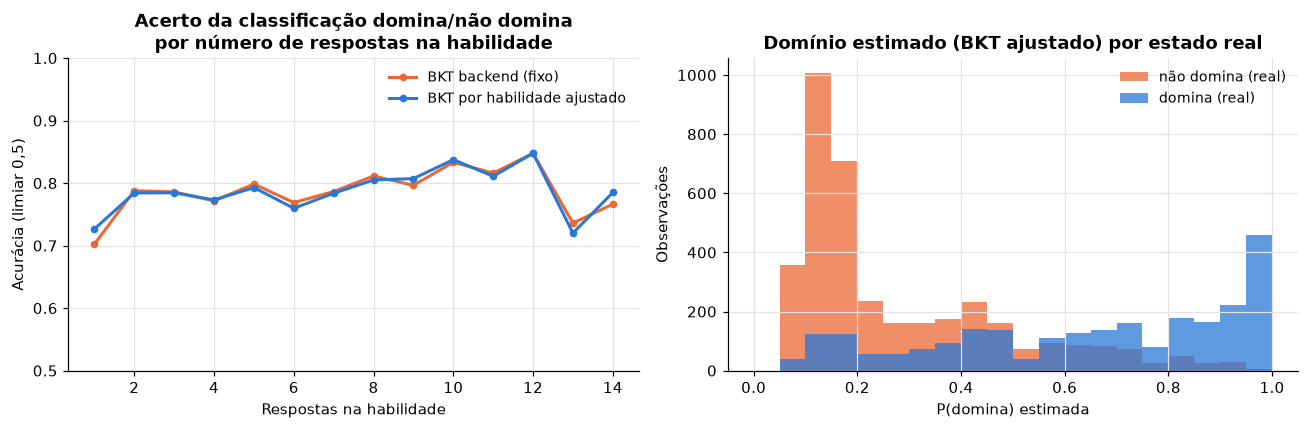

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax = axes[0]
for nome, cor in [('BKT backend (fixo)', COR['EVIDENCE']), ('BKT por habilidade ajustado', COR['SOURCE'])]:
    d = previsoes[nome]
    curva = d.groupby('tentativa').apply(
        lambda g: pd.Series({'acc': accuracy_score(g.domina_depois, g.dominio >= 0.5), 'n': len(g)}),
        include_groups=False)
    curva = curva[curva.n >= 100]
    ax.plot(curva.index, curva.acc, marker='o', markersize=4, color=cor, label=nome)
ax.set(title='Acerto da classificação domina/não domina\npor número de respostas na habilidade',
       xlabel='Respostas na habilidade', ylabel='Acurácia (limiar 0,5)', ylim=(0.5, 1))
ax.legend(frameon=False, fontsize=9)

ax = axes[1]
d = base
bins = np.linspace(0, 1, 21)
ax.hist(d.dominio[d.domina_depois == 0], bins=bins, color=COR['EVIDENCE'], alpha=0.75, label='não domina (real)')
ax.hist(d.dominio[d.domina_depois == 1], bins=bins, color=COR['SOURCE'], alpha=0.75, label='domina (real)')
ax.set(title='Domínio estimado (BKT ajustado) por estado real', xlabel='P(domina) estimada', ylabel='Observações')
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.savefig(FIGURAS / '04_dominio_vs_estado_real.png', bbox_inches='tight')
plt.show()

**Leitura:**
- **O domínio estimado separa bem quem domina de quem não domina.** A AUC é ≈ 0,84, e o histograma mostra as duas populações concentradas em lados opostos.
- **A decisão "domina" no limiar 0,95 tem um trade-off.**
  - O BKT calibrado quase nunca declara domínio por engano (precisão ≈ 0,98), mas é conservador: reconhece só ≈ 18% dos que realmente dominam.
  - O backend declara domínio duas vezes mais (revocação ≈ 0,32), à custa de mais falsos "domina" (precisão ≈ 0,93). Isso acontece porque um único acerto já o leva a 0,70.
  - Para um jogo educativo, dizer a alguém que ele domina uma habilidade quando não domina é o erro mais caro, então preferimos a precisão. O limiar pode ser ajustado conforme a regra de produto.
- **Acerto da classificação por número de respostas (limiar 0,5).** Ele sobe de ≈ 0,70–0,73 na 1ª resposta para ≈ 0,78 a partir da 2ª e depois fica estável. O platô vem do ruído de chute/deslize e do fato de que jogadores continuam aprendendo a cada rodada.
- **Consequência para o produto.** Com **3 perguntas por habilidade** no banco atual, cerca de 1 em cada 5 classificações domina/não domina ainda está errada.

### 5.2 Recuperação dos parâmetros e estabilidade (validação cruzada por jogador)

Se o procedimento de treino estiver correto, ele deve **recuperar os parâmetros que geraram os dados**, e de forma estável. Repetimos o ajuste em 5 *folds* agrupados por jogador (`GroupKFold`) sobre a base completa e medimos a variação dos parâmetros e da AUC/log-loss fora da amostra.

In [15]:
%%time
cv = GroupKFold(n_splits=5)
registros_params, registros_metricas = [], []
for fold, (itr, ite) in enumerate(cv.split(respostas, groups=respostas['user_id']), start=1):
    tr, te = respostas.iloc[itr], respostas.iloc[ite]
    p_fold = {}
    for s in SKILLS:
        Y, M, _ = montar_sequencias(tr, s)
        p_fold[s], _ = ajustar_bkt(Y, M, n_inicios=5, seed=SEED + fold)
        registros_params.append({'fold': fold, 'skill_code': s, **p_fold[s]})
    for nome, p in [('BKT backend (fixo)', {s: PARAMS_BACKEND for s in SKILLS}),
                    ('BKT por habilidade ajustado', p_fold)]:
        d = prever(te, p)
        registros_metricas.append({'fold': fold, 'modelo': nome, **metricas(d.y, d.p)})

cv_params = pd.DataFrame(registros_params)
cv_metricas = pd.DataFrame(registros_metricas)

recuperacao = cv_params.groupby('skill_code')[PARAMS].agg(['mean', 'std']).reindex(SKILLS)
erro_abs = (cv_params.groupby('skill_code')[PARAMS].mean().reindex(SKILLS)
            - pd.DataFrame(PARAMS_VERDADEIROS).T[PARAMS]).abs()
print('Parâmetros nos 5 folds (média e desvio-padrão):')
display(recuperacao.round(3))
print('Erro absoluto médio em relação ao valor verdadeiro:', round(float(erro_abs.values.mean()), 4))
print('\nMétricas fora da amostra nos 5 folds (média ± desvio-padrão):')
cv_metricas.groupby('modelo')[['AUC', 'log-loss', 'Brier']].agg(['mean', 'std']).round(4)

Parâmetros nos 5 folds (média e desvio-padrão):


p_init        p_guess        p_slip        p_transition       
             mean    std    mean    std   mean    std         mean    std
skill_code                                                               
SOURCE      0.360  0.009   0.321  0.007  0.097  0.001        0.143  0.005
EVIDENCE    0.272  0.013   0.291  0.008  0.094  0.008        0.118  0.003
CONTEXT     0.203  0.016   0.334  0.013  0.125  0.012        0.106  0.006
VISUAL      0.158  0.008   0.286  0.002  0.130  0.006        0.080  0.003

Erro absoluto médio em relação ao valor verdadeiro: 0.0096

Métricas fora da amostra nos 5 folds (média ± desvio-padrão):
CPU times: user 2.89 s, sys: 22.7 ms, total: 2.92 s
Wall time: 2.92 s


AUC         log-loss           Brier        
                               mean     std     mean     std    mean     std
modelo                                                                      
BKT backend (fixo)           0.6558  0.0124   0.6638  0.0078  0.2343  0.0032
BKT por habilidade ajustado  0.6652  0.0097   0.6417  0.0055  0.2259  0.0024

## 6. Sensibilidade: o efeito do `p_guess` do backend

O backend usa `p_guess=0,20`, valor típico de perguntas com 5 alternativas. As 12 perguntas do banco têm **3 alternativas**, então quem chuta acerta cerca de 1/3 das vezes. O modelo atual interpreta esses acertos de chute como evidência forte de domínio. Abaixo variamos **só** o `p_guess` (mantendo os demais parâmetros do backend) e medimos log-loss no teste e precisão da decisão "domina".

In [16]:
linhas = []
for g in [0.10, 0.15, 0.20, 0.25, 0.30, 1 / 3, 0.40]:
    p = {**PARAMS_BACKEND, 'p_guess': g}
    d = prever(teste, {s: p for s in SKILLS})
    linhas.append({'p_guess': round(g, 3), 'log-loss': log_loss(d.y, d.p),
                   'precisão "domina"': precision_score(d.domina_depois, d.dominio >= LIMIAR_DOMINIO, zero_division=0),
                   'domínio após 1 acerto': BKTEngine(**p).update(0.30, True)})
sens = pd.DataFrame(linhas).set_index('p_guess')
sens.round(4)

,log-loss,"precisão ""domina""",domínio após 1 acerto
p_guess,,,
0.100,0.7193,0.8792,0.8225
0.150,0.6875,0.9025,0.7577
0.200,0.6683,0.9336,0.7035
0.250,0.6572,0.9780,0.6576
0.300,0.6524,0.9797,0.6182
0.333,0.6522,0.9853,0.5949
0.400,0.6585,0.9920,0.5540


Mudando **apenas** o `p_guess` para ≈ 1/3, o log-loss do modelo do backend cai de 0,668 para 0,652, quase o mesmo do BKT totalmente calibrado. A precisão da decisão "domina" sobe de 0,93 para 0,99. Um único acerto deixa de levar o jogador de 0,30 para 0,70 de domínio (passa a 0,59). Esta é a principal recomendação prática para o backend: é uma mudança de uma linha em cada tracker.

## 7. Execução nos dados reais disponíveis

Aplicamos o modelo às 10 respostas reais do usuário de teste (seção 2.1) e comparamos o domínio final de cada habilidade com o modelo do backend e com o modelo calibrado. Com tão poucas respostas, isto é uma **demonstração de execução**, não uma avaliação.

In [17]:
reais = respostas_reais.sort_values('created_at')
tabela = {}
for nome, p in [('backend', {s: PARAMS_BACKEND for s in SKILLS}), ('calibrado', params_ajustados)]:
    dom = {s: p[s]['p_init'] for s in SKILLS}
    for _, r in reais.iterrows():
        pr = p[r.skill_code]
        dom[r.skill_code] = BKTEngine(**pr).update(dom[r.skill_code], bool(r.correct))
    tabela[f'domínio final ({nome})'] = dom
pd.DataFrame(tabela).assign(
    respostas=reais.groupby('skill_code').size(),
    sequência=reais.groupby('skill_code')['correct'].apply(lambda c: ''.join('✓' if x else '✗' for x in c)),
).reindex(SKILLS).round(3)

,domínio final (backend),domínio final (calibrado),respostas,sequência
SOURCE,0.115,0.214,3,✓✗✗
EVIDENCE,0.115,0.152,3,✓✗✗
CONTEXT,0.704,0.487,1,✓
VISUAL,0.146,0.149,3,✗✓✗


O caso de `CONTEXT` resume a diferença entre os dois modelos. Com **uma única resposta certa**, o backend já declara 70% de domínio. O modelo calibrado, que sabe que um terço dos acertos pode ser chute, fica abaixo de 50%. Nas outras habilidades, os dois erros seguidos derrubam o domínio em ambos.

## 8. Persistência do modelo

O arquivo `modelos/bkt_modelo.pkl` guarda um **dicionário** (não uma classe customizada), então pode ser lido sem importar código do projeto. Ele contém os parâmetros calibrados por habilidade, os parâmetros do backend para comparação, o limiar de domínio, as métricas de avaliação e os metadados de proveniência (**dados sintéticos**, data, versões das bibliotecas).

> Pickle pode executar código ao ser carregado: carregue apenas arquivos de origem confiável.

In [18]:
def para_float(d):
    return {k: (para_float(v) if isinstance(v, dict) else float(v)) for k, v in d.items()}

modelo = {
    'schema_version': 2,
    'model_type': 'Bayesian Knowledge Tracing (Corbett & Anderson, 1995), um conjunto de parâmetros por habilidade',
    'skills': SKILLS,
    'parameters': para_float(params_ajustados),
    'parameters_backend_atual': dict(PARAMS_BACKEND),
    'parameters_global': para_float(params_global),
    'mastery_threshold': LIMIAR_DOMINIO,
    'metrics_test': {k: para_float(v) for k, v in resultados.T.to_dict().items()},
    'metrics_mastery_test': {k: para_float(v) for k, v in dominio_resultados.T.to_dict().items()},
    'training': {
        'method': 'máxima verossimilhança (algoritmo forward), L-BFGS-B com limites, 10 inícios',
        'split': 'GroupShuffleSplit por jogador, 70/30, seed=%d' % SEED,
        'n_players_train': int(treino.user_id.nunique()), 'n_answers_train': int(len(treino)),
        'n_players_test': int(teste.user_id.nunique()), 'n_answers_test': int(len(teste)),
    },
    'data': {'source': 'sintético: processo gerador do BKT + seletor adaptativo do backend',
             'is_synthetic': True, 'seed': SEED, 'true_parameters': PARAMS_VERDADEIROS},
    'implementation': 'src/bkt_engine.py (cópia de backend/app/bkt/engine.py)',
    'trained_at_utc': datetime.now(timezone.utc).isoformat(timespec='seconds'),
    'versions': {'python': platform.python_version(), 'numpy': np.__version__, 'scipy': scipy.__version__,
                 'scikit-learn': sklearn.__version__},
}
CAMINHO_MODELO = MODELOS / 'bkt_modelo.pkl'
with CAMINHO_MODELO.open('wb') as f:
    pickle.dump(modelo, f, protocol=pickle.HIGHEST_PROTOCOL)
print('Salvo em', CAMINHO_MODELO.relative_to(ENTREGA), f'({CAMINHO_MODELO.stat().st_size} bytes)')

Salvo em modelos/bkt_modelo.pkl (2263 bytes)


### 8.1 Carregar o `.pkl` e usar o modelo

O código abaixo é tudo de que um consumidor precisa: carregar o arquivo, criar um motor por habilidade e atualizar o domínio a cada resposta, como o backend faz.

In [19]:
with (MODELOS / 'bkt_modelo.pkl').open('rb') as f:
    carregado = pickle.load(f)

motores = {s: BKTEngine(**carregado['parameters'][s]) for s in carregado['skills']}


def atualizar(skill, dominio, correta):
    return motores[skill].update(dominio, correta)


def prob_acerto(skill, dominio):
    m = motores[skill]
    return dominio * (1 - m.p_slip) + (1 - dominio) * m.p_guess


dominio = carregado['parameters']['VISUAL']['p_init']
print(f"VISUAL | domínio inicial {dominio:.3f} | P(acerto) {prob_acerto('VISUAL', dominio):.3f}")
for correta in [True, False, True, True, True]:
    dominio = atualizar('VISUAL', dominio, correta)
    print(f"{'acerto' if correta else 'erro  '} -> domínio {dominio:.3f} | P(próximo acerto) {prob_acerto('VISUAL', dominio):.3f}"
          + ('  [domina]' if dominio >= carregado['mastery_threshold'] else ''))

# O modelo recarregado reproduz exatamente as previsões avaliadas acima
d_rec = prever(teste, carregado['parameters'])
assert np.allclose(d_rec.p, base.p)
print('\nModelo recarregado reproduz as previsões do teste. Origem dos dados:', carregado['data']['source'])

VISUAL | domínio inicial 0.156 | P(acerto) 0.372
acerto -> domínio 0.414 | P(próximo acerto) 0.524
erro   -> domínio 0.179 | P(próximo acerto) 0.386
acerto -> domínio 0.450 | P(próximo acerto) 0.546
acerto -> domínio 0.740 | P(próximo acerto) 0.718
acerto -> domínio 0.906 | P(próximo acerto) 0.816

Modelo recarregado reproduz as previsões do teste. Origem dos dados: sintético: processo gerador do BKT + seletor adaptativo do backend


## 9. Conclusões

- **O BKT é adequado ao problema.** Ele é interpretável (quatro parâmetros com significado pedagógico), atualiza online com uma conta O(1) por resposta, funciona com pouco dado por jogador e produz exatamente o que o seletor adaptativo precisa: uma probabilidade de domínio por habilidade.
- **O pipeline de calibração funciona.** Ele recupera os parâmetros que geraram os dados, com erro absoluto médio ≈ 0,01 e desvio-padrão ≤ 0,016 entre folds. O BKT calibrado por habilidade supera os baselines e o BKT com valores fixos em log-loss, Brier e AUC no teste com jogadores novos e nos 5 folds da validação cruzada.
- **Os valores fixos atuais do backend estão mal calibrados para perguntas de 3 alternativas.** O `p_guess=0,20` faz um acerto valer demais. Recomendação imediata: `p_guess≈0,33`.
- **Limite principal:** os números de desempenho vêm de dados **simulados** sob hipóteses explícitas. Eles validam o método, não o comportamento de jogadores reais. Com respostas reais no formato `user_id, skill_code, correct, created_at`, basta substituir a base da seção 2.2 e reexecutar o notebook.
- **Consequência para o produto:** com 3 perguntas por habilidade, o domínio estimado ainda é incerto. Ampliar o banco de perguntas é tão importante quanto calibrar o modelo.

**Referências:** Corbett, A. T.; Anderson, J. R. (1995). *Knowledge tracing: Modeling the acquisition of procedural knowledge*. User Modeling and User-Adapted Interaction, 4(4). Baker, R. S. J. d.; Corbett, A. T.; Aleven, V. (2008). *More accurate student modeling through contextual estimation of slip and guess probabilities in Bayesian Knowledge Tracing*. ITS 2008. Pardos, Z. A.; Heffernan, N. T. (2011). *KT-IDEM: Introducing item difficulty to the Knowledge Tracing model*. UMAP 2011.